# Satellite Image Classification (Urban vs. Natural) Using Classical Vision + ML
**Course:** Computer Vision (S2-25_AIMLCZG525)

**Group:** 34

**Group Members:**

| Name | BITS Id |
|---|---|
| AJIT SUBRAMANIAM V | 2025aa05930 |
| NAGARJUNA MANUPATI | 2025aa05895 |
| MAHADEVA SWAMY B N | 2025ab05081 |
| MAHENDRAN K | 2025aa05777 |

Build a classical machine-learning system that classifies satellite images into Urban or Natural categories using handcrafted image features. The system must incorporate pixel level, texture, and gradient-based features and evaluate performance on a real external image.

---

### Pipeline Overview
1. Dataset Preparation (EuroSAT – Urban vs Natural, ~500 each)
2. Preprocessing (resize, grayscale, CLAHE, Gaussian blur)
3. Feature Engineering (Histogram, LBP, Edges, HOG)
4. Feature Selection (PCA)
5. Model Training (SVM + Random Forest, 5-fold CV)
6. Evaluation (Accuracy, Precision, Recall, F1, Confusion Matrix)
7. Model Inference – 5 Random Test Images
8. External Real-World Image Validation
9. Analysis & Discussion

---
## Part 0 – Import Required Libraries

In [1]:
# ── Standard Library ──────────────────────────────────────────────────────────
import os
import random
import warnings
import pickle
#import kagglehub # Moved here
warnings.filterwarnings('ignore') # Ignoring warnings broadly for cleaner notebook output

# ── Numerical & Data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Image Processing ──────────────────────────────────────────────────────────
from PIL import Image                        # image loading
import cv2                                      # OpenCV for image I/O and processing
from skimage.feature import hog, local_binary_pattern  # HOG and LBP
from skimage import exposure
import skimage # Import skimage to get its version

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Machine Learning ──────────────────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.pipeline import Pipeline
import sklearn # Import sklearn to get its version

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("All libraries imported successfully.")
print(f"   OpenCV       : {cv2.__version__}")
print(f"   NumPy        : {np.__version__}")
print(f"   Pandas       : {pd.__version__}")
print(f"   Scikit-image : {skimage.__version__}") # Added
print(f"   Scikit-learn : {sklearn.__version__}") # Added

All libraries imported successfully.
   OpenCV       : 4.13.0
   NumPy        : 2.0.2
   Pandas       : 2.2.2
   Scikit-image : 0.25.2
   Scikit-learn : 1.6.1


---
## Part 1 — Data Acquisition and Loading

### About the fMoW-RGB Dataset
The **Functional Map of the World (fMoW)** dataset contains satellite images classified into **62 fine-grained land-use and building categories** (e.g., airport, hospital, forest, park).  
- Full dataset size: ~53 GB (hosted on AWS S3).
- Image resolution: 224 × 224 × 3 RGB (after processing).
- For this assignment we **binary-map** all 62 classes → `Urban (1)` or `Natural (0)`.

**Download options:**
1. **Google Colab + AWS CLI** (recommended for Colab users) — see Cell below.
2. **Local** — mount your local fMoW-RGB directory and set `DATASET_ROOT`.
3. **Kaggle** — a curated fMoW subset is available at `kaggle datasets download -d ipythonx/fmow-satellite-urban-rural`.

> **Note:** The full dataset is ~53 GB. For this assignment we sample **≤ 500 images per binary class** (~1 000 images total), which is sufficient to demonstrate all feature-engineering and ML concepts without requiring the complete download.


---
### 1.1 — (Optional) Download fMoW-RGB via AWS CLI (Colab)
Run this cell only if working on **Google Colab** and you have not yet downloaded the data.  
It downloads a curated 1 000-image subset (500 Urban + 500 Natural) from the official fMoW S3 bucket.

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Dataset Download (Colab / first-time setup)
# Skip this cell if you already have the data locally.
# ─────────────────────────────────────────────────────────────────────────────

DOWNLOAD_DATA = True   # ← Set True to trigger download on Colab

if DOWNLOAD_DATA:
    import subprocess, sys

    # Install AWS CLI (Colab already has it; this is a safety check)
    subprocess.run(['pip', 'install', 'awscli', '-q'], check=True)

    # ── fMoW-RGB is a public S3 dataset (no AWS credentials required) ───────────
    # We download a selection of categories that map cleanly to Urban / Natural.

    # Urban categories to download (subset of 62)
    URBAN_DL   = ['airport', 'construction_site', 'office_building',
                  'shopping_mall', 'stadium', 'single-unit_residential',
                  'multi-unit_residential', 'industrial_facility']

    # Natural categories to download
    NATURAL_DL = ['park', 'lake_or_pond', 'crop_field', 'golf_course',
                  'wind_farm']

    S3_BASE = 's3://spacenet-dataset/Hosted-Datasets/fmow/fmow-rgb/train'
    LOCAL_BASE = './fmow_rgb'

    os.makedirs(f'{LOCAL_BASE}/urban',   exist_ok=True)
    os.makedirs(f'{LOCAL_BASE}/natural', exist_ok=True)

    for cat in URBAN_DL:
        dst = f'{LOCAL_BASE}/urban/{cat}'
        cmd = ['aws', 's3', 'sync', '--no-sign-request',
               f'{S3_BASE}/{cat}', dst, '--exclude', '*',
               '--include', '*_rgb.jpg', '--quiet']
        print(f'  Downloading urban/{cat} …')
        subprocess.run(cmd)

    for cat in NATURAL_DL:
        dst = f'{LOCAL_BASE}/natural/{cat}'
        cmd = ['aws', 's3', 'sync', '--no-sign-request',
               f'{S3_BASE}/{cat}', dst, '--exclude', '*',
               '--include', '*_rgb.jpg', '--quiet']
        print(f'  Downloading natural/{cat} …')
        subprocess.run(cmd)

    print('\n✓ Download complete.')
else:
    print('Download skipped — using existing local data.')


✓ Download complete.


---
### 1.2 — Binary Label Mapping

All 62 fMoW categories are mapped to a binary label:
- **Urban  (1):** human-built structures — airports, offices, stadiums, residential areas, etc.
- **Natural (0):** open-land, water bodies, vegetation, parks — areas with minimal human construction.

Some borderline categories (e.g., `crop_field`, `golf_course`) are assigned to Natural because they are characterised by open/green landscape textures rather than dense built surfaces.

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Define binary label mapping for all 62 fMoW categories
# ─────────────────────────────────────────────────────────────────────────────

# All 62 fMoW categories (source: https://github.com/fMoW/dataset)
ALL_FMOW_CATEGORIES = [
    "airport", "airport_hangar", "airport_terminal", "amusement_park",
    "aquaculture", "archaeological_site", "barn", "border_checkpoint",
    "burial_site", "car_dealership", "construction_site", "crop_field",
    "dam", "debris_or_rubble", "educational_institution", "electric_substation",
    "factory_or_powerplant", "fire_station", "flooded_road", "fountain",
    "gas_station", "golf_course", "ground_transportation_station", "helipad",
    "hospital", "impoverished_settlement", "interchange", "lake_or_pond",
    "lighthouse", "military_facility", "multi-unit_residential",
    "nuclear_powerplant", "office_building", "oil_or_gas_facility", "park",
    "parking_lot_or_garage", "place_of_worship", "police_station", "port",
    "prison", "race_track", "railway_bridge", "recreational_facility",
    "road_bridge", "runway", "shipyard", "shopping_mall",
    "single-unit_residential", "smokestack", "solar_farm", "space_facility",
    "stadium", "storage_tank", "surface_mine", "swimming_pool", "toll_booth",
    "tower", "tunnel_opening", "waste_disposal", "water_treatment_facility",
    "wind_farm", "zoo"
]

# ── Natural: open land, water, vegetation, minimal built infrastructure ────────
NATURAL_CATEGORIES = {
    "lake_or_pond",       # open water body
    "park",               # green open space
    "crop_field",         # agricultural land — open texture
    "golf_course",        # managed green landscape
    "wind_farm",          # sparse structure on open land
    "solar_farm",         # semi-natural open land use
    "aquaculture",        # water-based land use
    "flooded_road",       # transitional — water dominated
    "surface_mine",       # open terrain / bare earth
    "archaeological_site" # open terrain, minimal current structures
}

# ── Urban: all remaining built-environment categories ─────────────────────────
URBAN_CATEGORIES = set(ALL_FMOW_CATEGORIES) - NATURAL_CATEGORIES

# ── Build lookup dict:  category_name → binary label ─────────────────────────
#   0 = Natural,  1 = Urban
CATEGORY_TO_LABEL = {}
for cat in ALL_FMOW_CATEGORIES:
    CATEGORY_TO_LABEL[cat] = 0 if cat in NATURAL_CATEGORIES else 1

LABEL_NAMES = {0: 'Natural', 1: 'Urban'}

print(f"Total fMoW categories : {len(ALL_FMOW_CATEGORIES)}")
print(f"  → Urban   (label=1) : {len(URBAN_CATEGORIES)}")
print(f"  → Natural (label=0) : {len(NATURAL_CATEGORIES)}")
print("\nNatural categories:")
for c in sorted(NATURAL_CATEGORIES):
    print(f"  {c}")

Total fMoW categories : 62
  → Urban   (label=1) : 52
  → Natural (label=0) : 10

Natural categories:
  aquaculture
  archaeological_site
  crop_field
  flooded_road
  golf_course
  lake_or_pond
  park
  solar_farm
  surface_mine
  wind_farm


---
### 1.3 — Load Images from Disk

**Expected folder structure (either layout is supported):**

```
Layout A — binary folders (pre-sorted):
  fmow_rgb/
    urban/
      airport_0_rgb.jpg
      office_building_0_rgb.jpg  …
    natural/
      park_0_rgb.jpg
      lake_or_pond_0_rgb.jpg  …

Layout B — original fMoW category folders:
  fmow_rgb/train/
    airport/
      airport_0/
        airport_0_rgb.jpg  …
    park/
      park_0/
        park_0_rgb.jpg  …
```

Set `DATASET_ROOT` and `LAYOUT` below accordingly.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Configuration: set your dataset path here
# ─────────────────────────────────────────────────────────────────────────────

# ── UPDATE THIS PATH to point to your fMoW-RGB folder ────────────────────────
DATASET_ROOT = './fmow_rgb'     # e.g. '/content/fmow_rgb' on Colab

# ── Layout A = pre-sorted binary folders  (urban/ and natural/ subfolders)
# ── Layout B = original fMoW category folders  (airport/, park/, etc.)
LAYOUT = 'B'                    # 'A' or 'B'

# Target image dimensions (required by the assignment)
IMG_SIZE = (128, 128)           # resize to 128×128

# Max images per binary class — keeps the dataset balanced and manageable
MAX_PER_CLASS = 750

print(f"Dataset root : {DATASET_ROOT}")
print(f"Layout       : {LAYOUT}")
print(f"Image size   : {IMG_SIZE}")
print(f"Max / class  : {MAX_PER_CLASS}")

Dataset root : ./fmow_rgb
Layout       : B
Image size   : (128, 128)
Max / class  : 750


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Image loading utilities
# ─────────────────────────────────────────────────────────────────────────────

SUPPORTED_EXTS = ('.jpg', '.jpeg', '.png', '.tif', '.tiff')


def collect_files_layout_a(root, max_per_class, seed=SEED):
    """
    Layout A: root/urban/*.jpg  and  root/natural/*.jpg
    Returns list of (filepath, label) tuples.
    """
    rng = np.random.default_rng(seed)
    records = []
    for label_name, label_idx in [('urban', 1), ('natural', 0)]:
        folder = os.path.join(root, label_name)
        if not os.path.isdir(folder):
            print(f"  [WARN] folder not found: {folder}")
            continue
        files = [
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith(SUPPORTED_EXTS)
        ]
        if len(files) > max_per_class:
            files = list(rng.choice(files, max_per_class, replace=False))
        records.extend([(f, label_idx) for f in files])
    return records


def collect_files_layout_b(root, category_label_map, max_per_class, seed=SEED):
    """
    Layout B: root/<category>/<sequence>/<category>_<seq>_rgb.jpg
    Also adapted to handle structure created by cell_download:
    root/urban/<category>/<sequence>/... and root/natural/<category>/<sequence>/...
    Recursively walks each category subfolder.
    Returns list of (filepath, label) tuples.
    """
    rng   = np.random.default_rng(seed)
    # Collect per binary-class so we can cap at max_per_class
    buckets = {0: [], 1: []}   # 0=Natural, 1=Urban

    # Determine the actual top-level folders to scan for categories
    # This checks if 'urban' and 'natural' exist as direct subdirectories of root.
    # If they do, it means the structure is root/urban/<category> or root/natural/<category>.
    # Otherwise, it assumes root directly contains category folders (Layout B standard).
    top_level_scan_paths = []
    urban_path = os.path.join(root, 'urban')
    natural_path = os.path.join(root, 'natural')

    if os.path.isdir(urban_path) and os.path.isdir(natural_path):
        top_level_scan_paths.extend([urban_path, natural_path])
    elif os.path.isdir(urban_path): # Only urban exists
        top_level_scan_paths.append(urban_path)
    elif os.path.isdir(natural_path): # Only natural exists
        top_level_scan_paths.append(natural_path)
    else:
        top_level_scan_paths.append(root) # Assume categories are directly under root

    for current_scan_path in top_level_scan_paths:
        if not os.path.isdir(current_scan_path):
            print(f"  [WARN] Directory not found: {current_scan_path}. Skipping.")
            continue

        for entry in sorted(os.scandir(current_scan_path), key=lambda e: e.name):
            if not entry.is_dir():
                continue
            cat_name = entry.name.lower()
            if cat_name not in category_label_map:
                print(f"  [WARN] Skipping unknown category folder: {cat_name} in {current_scan_path}")
                continue
            label = category_label_map[cat_name]

            # Walk recursively — handles both flat and nested sub-dirs
            for dirpath, _, filenames in os.walk(entry.path):
                for fname in filenames:
                    if fname.lower().endswith(SUPPORTED_EXTS):
                        buckets[label].append(os.path.join(dirpath, fname))

    records = []
    for label_idx, files in buckets.items():
        if len(files) > max_per_class:
            files = list(rng.choice(files, max_per_class, replace=False))
        records.extend([(f, label_idx) for f in files])
    return records


def load_image(path, size):
    """
    Load one image, convert to RGB, resize to `size`.
    Returns uint8 NumPy array of shape (H, W, 3), or None on failure.
    """
    try:
        img = Image.open(path).convert('RGB')
        img = img.resize(size, Image.LANCZOS)  # high-quality downscaling
        return np.array(img, dtype=np.uint8)
    except Exception as e:
        print(f"  [WARN] Skipping {os.path.basename(path)}: {e}")
        return None


def load_dataset(root, layout, category_label_map, img_size, max_per_class):
    """
    Master loading function.
    Returns:
        images  : np.ndarray (N, H, W, 3)  uint8
        labels  : np.ndarray (N,)           int  {0, 1}
        paths   : list of str               original file paths
    """
    if layout == 'A':
        records = collect_files_layout_a(root, max_per_class)
    elif layout == 'B':
        records = collect_files_layout_b(root, category_label_map, max_per_class)
    else:
        raise ValueError(f"Unknown layout '{layout}'. Choose 'A' or 'B'.")

    print(f"Found {len(records)} candidate image paths. Loading …")

    images, labels, paths = [], [], []
    for i, (fpath, label) in enumerate(records):
        if i % 200 == 0 and i > 0:
            print(f"  Loaded {i}/{len(records)} …")
        arr = load_image(fpath, img_size)
        if arr is not None:
            images.append(arr)
            labels.append(label)
            paths.append(fpath)

    return (
        np.array(images, dtype=np.uint8),
        np.array(labels, dtype=np.int32),
        paths
    )


print("✓ Loading utilities defined.")

✓ Loading utilities defined.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Load the dataset
# ─────────────────────────────────────────────────────────────────────────────

images, labels, img_paths = load_dataset(
    root              = DATASET_ROOT,
    layout            = LAYOUT,
    category_label_map= CATEGORY_TO_LABEL,
    img_size          = IMG_SIZE,
    max_per_class     = MAX_PER_CLASS
)

# ── Summary ──────────────────────────────────────────────────────────────────
n_urban   = int(np.sum(labels == 1))
n_natural = int(np.sum(labels == 0))
n_total   = len(images)

print("\n" + "="*50)
print("  DATASET SUMMARY")
print("="*50)
print(f"  Total images loaded : {n_total}")
print(f"  Image shape         : {images[0].shape}  (H×W×C)")
print(f"  Image dtype         : {images.dtype}")
print(f"  Urban   (label=1)   : {n_urban}  ({n_urban/n_total*100:.1f}%))")
print(f"  Natural (label=0)   : {n_natural}  ({n_natural/n_total*100:.1f}%))")
print(f"  Pixel value range   : [{images.min()}, {images.max()}])")
print("="*50)

  [WARN] Skipping unknown category folder: industrial_facility in ./fmow_rgb/urban
Found 1500 candidate image paths. Loading …
  Loaded 200/1500 …
  Loaded 400/1500 …
  Loaded 600/1500 …
  Loaded 800/1500 …
  Loaded 1000/1500 …
  [WARN] Skipping airport_102_0_rgb.jpg: Image size (196672000 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
  Loaded 1200/1500 …
  [WARN] Skipping airport_417_1_rgb.jpg: Image size (258051871 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.
  Loaded 1400/1500 …

  DATASET SUMMARY
  Total images loaded : 1498
  Image shape         : (128, 128, 3)  (H×W×C)
  Image dtype         : uint8
  Urban   (label=1)   : 748  (49.9%))
  Natural (label=0)   : 750  (50.1%))
  Pixel value range   : [0, 255])


---
### 1.4 — Category-wise Image Count

We derive the per-category count from the file paths (which embed the category name in the fMoW naming convention: `<category>_<id>_rgb.jpg`).

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Category-wise image count (derived from file paths)
# ─────────────────────────────────────────────────────────────────────────────

def extract_category(path):
    """
    Infer fMoW category from file path.
    Works for both Layout A and Layout B.
    """
    basename  = os.path.basename(path)      # e.g.  airport_0_rgb.jpg
    parent    = os.path.basename(           # parent folder name
                    os.path.dirname(path))
    grandpar  = os.path.basename(
                    os.path.dirname(
                        os.path.dirname(path)))

    # Try to match a known category from the path components
    for token in [parent, grandpar]:
        if token.lower() in CATEGORY_TO_LABEL:
            return token.lower()
    # Fallback: strip '_rgb.jpg' suffix and last id segment from filename
    name = basename.replace('_rgb.jpg', '').replace('_rgb.jpeg', '')
    parts = name.rsplit('_', 1)
    if len(parts) == 2 and parts[0].lower() in CATEGORY_TO_LABEL:
        return parts[0].lower()
    return 'unknown'

# Build a DataFrame for easy aggregation
meta_df = pd.DataFrame({
    'path'    : img_paths,
    'label'   : labels,
    'category': [extract_category(p) for p in img_paths]
})
meta_df['class_name'] = meta_df['label'].map(LABEL_NAMES)

# Category-wise count
cat_counts = (
    meta_df.groupby(['class_name', 'category'])
           .size()
           .reset_index(name='count')
           .sort_values(['class_name', 'count'], ascending=[True, False])
)

print("Category-wise image counts:\n")
print(cat_counts.to_string(index=False))
print(f"\nTotal: {cat_counts['count'].sum()} images across "
      f"{cat_counts['category'].nunique()} categories")

Category-wise image counts:

class_name                category  count
   Natural              crop_field    460
   Natural                    park    104
   Natural               wind_farm     93
   Natural             golf_course     70
   Natural            lake_or_pond     23
     Urban single-unit_residential    195
     Urban  multi-unit_residential    158
     Urban           shopping_mall    109
     Urban         office_building    106
     Urban                 stadium    106
     Urban       construction_site     50
     Urban                 airport     24

Total: 1498 images across 12 categories


---
### 1.5 — Distribution Plots

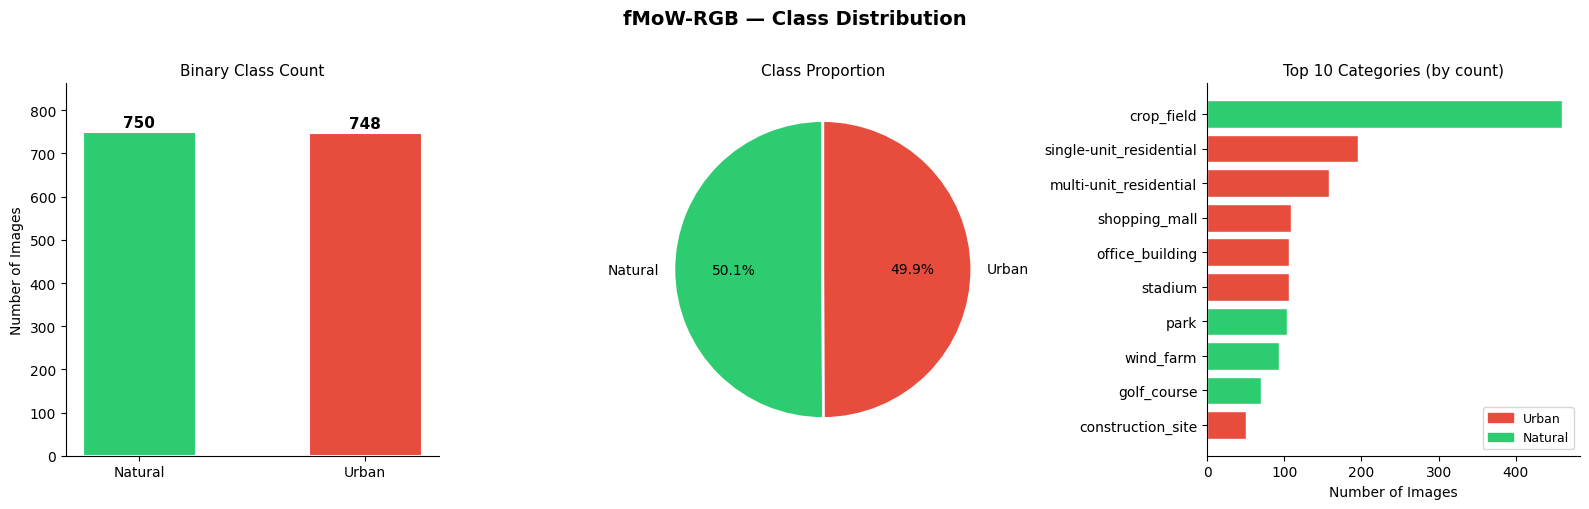

Plot saved → class_distribution.png


In [9]:
import matplotlib.patches as mpatches

CLASS_COLORS = {'Urban': '#E74C3C', 'Natural': '#2ECC71'}

binary_counts = meta_df['class_name'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('fMoW-RGB — Class Distribution', fontsize=14, fontweight='bold', y=1.01)

# ── (A) Binary bar chart ──────────────────────────────────────────────────────
ax = axes[0]
colors_bar = [CLASS_COLORS[c] for c in binary_counts.index]
bars = ax.bar(binary_counts.index, binary_counts.values,
              color=colors_bar, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, binary_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 4, str(val),
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Binary Class Count', fontsize=11)
ax.set_ylabel('Number of Images')
ax.set_ylim(0, binary_counts.max() * 1.15)
ax.spines[['top','right']].set_visible(False)

# ── (B) Pie chart ─────────────────────────────────────────────────────────────
ax = axes[1]
wedge_colors = [CLASS_COLORS[c] for c in binary_counts.index]
ax.pie(binary_counts.values,
       labels=binary_counts.index,
       autopct='%1.1f%%',
       colors=wedge_colors,
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Class Proportion', fontsize=11)

# ── (C) Category-level bar chart (top 10 most frequent) ───────────────────────
ax = axes[2]
top_cats = cat_counts.nlargest(10, 'count')
cat_colors = [CLASS_COLORS['Urban'] if
              CATEGORY_TO_LABEL.get(r['category'], 1) == 1 else CLASS_COLORS['Natural']
              for _, r in top_cats.iterrows()]
ax.barh(top_cats['category'], top_cats['count'],
        color=cat_colors, edgecolor='white', linewidth=1)
ax.set_title('Top 10 Categories (by count)', fontsize=11)
ax.set_xlabel('Number of Images')
ax.invert_yaxis()
ax.spines[['top','right']].set_visible(False)
# Add legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in CLASS_COLORS.items()]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → class_distribution.png")

---
### 1.6 — Sample Image Visualisation

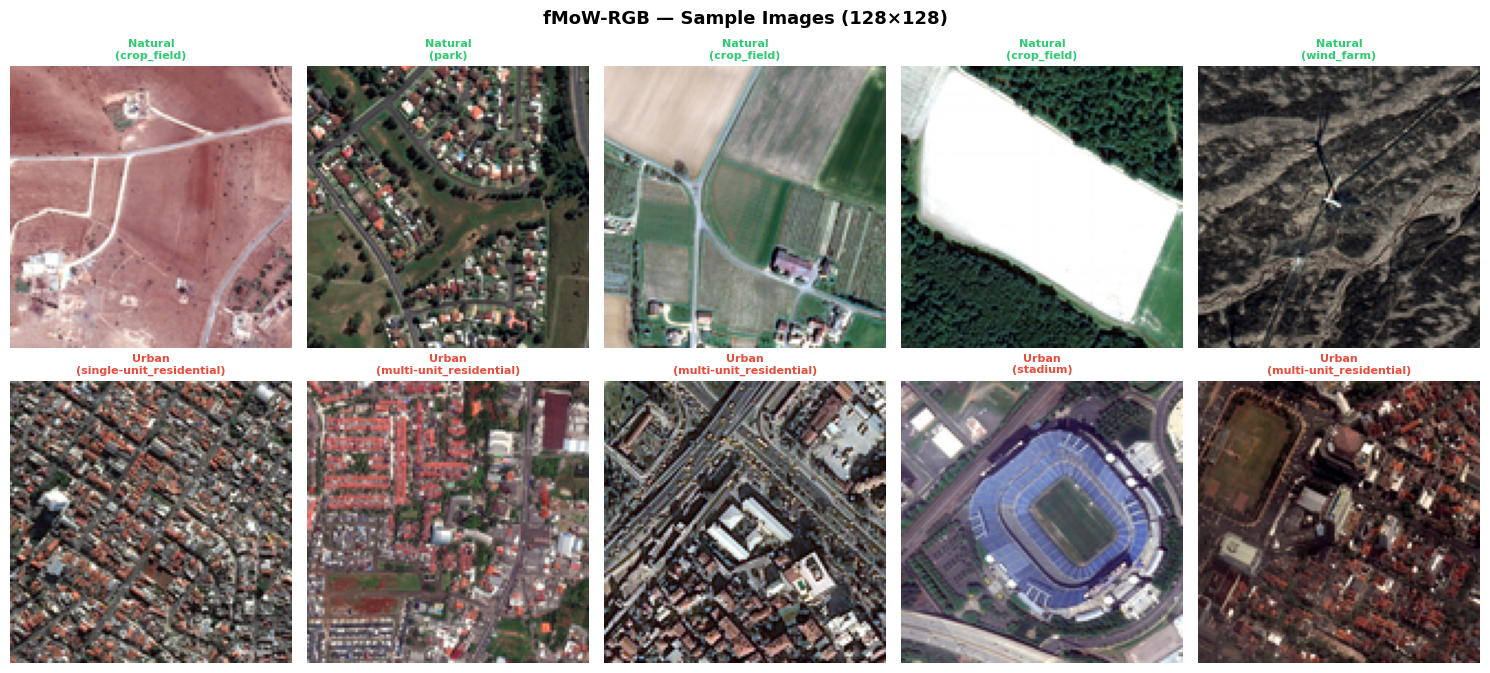

Plot saved → sample_images.png


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Display 5 random sample images per class
# ─────────────────────────────────────────────────────────────────────────────

N_SAMPLES = 5
fig, axes = plt.subplots(2, N_SAMPLES, figsize=(N_SAMPLES * 3, 7))
fig.suptitle('fMoW-RGB — Sample Images (128×128)', fontsize=13, fontweight='bold')

for row, (lbl, lbl_name) in enumerate(LABEL_NAMES.items()):
    idx_pool = np.where(labels == lbl)[0]
    chosen   = np.random.choice(idx_pool, N_SAMPLES, replace=False)
    for col, idx in enumerate(chosen):
        axes[row, col].imshow(images[idx])
        # Try to show category name in subtitle
        cat = extract_category(img_paths[idx])
        axes[row, col].set_title(
            f"{lbl_name}\n({cat})",
            fontsize=8, color=CLASS_COLORS[lbl_name], fontweight='bold'
        )
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → sample_images.png")

---
### 1.7 — Train / Test Split (80 : 20, Stratified)

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Stratified 80:20 train/test split
#
# Stratification ensures both Urban and Natural classes are proportionally
# represented in both the training and test sets, preventing evaluation bias.
# ─────────────────────────────────────────────────────────────────────────────

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    images,
    labels,
    test_size    = 0.20,      # 20% held-out test set
    random_state = SEED,
    stratify     = labels     # preserves class ratio in both splits
)

# ── Verification ──────────────────────────────────────────────────────────────
print("=" * 55)
print("  STRATIFIED TRAIN / TEST SPLIT")
print("=" * 55)
print(f"  Training set  : {len(X_train_raw):>4d} images")
print(f"    Urban       : {np.sum(y_train==1):>4d}  "
      f"({np.sum(y_train==1)/len(y_train)*100:.1f}%)")
print(f"    Natural     : {np.sum(y_train==0):>4d}  "
      f"({np.sum(y_train==0)/len(y_train)*100:.1f}%)")
print(f"  Test set      : {len(X_test_raw):>4d} images")
print(f"    Urban       : {np.sum(y_test==1):>4d}  "
      f"({np.sum(y_test==1)/len(y_test)*100:.1f}%)")
print(f"    Natural     : {np.sum(y_test==0):>4d}  "
      f"({np.sum(y_test==0)/len(y_test)*100:.1f}%)")
print("=" * 55)
print("\n✓ Part 1 complete. Data ready for preprocessing (Part 2).")

  STRATIFIED TRAIN / TEST SPLIT
  Training set  : 1198 images
    Urban       :  598  (49.9%)
    Natural     :  600  (50.1%)
  Test set      :  300 images
    Urban       :  150  (50.0%)
    Natural     :  150  (50.0%)

✓ Part 1 complete. Data ready for preprocessing (Part 2).


In [ ]:
# ── Compatibility bridge ─────────────────────────────────────────────────────
# Alias fMoW variables to names used by preprocessing and downstream cells
# fMoW: images (np.ndarray uint8 RGB), labels (np.int32: 0=Natural,1=Urban)
# Downstream expects: all_images (list of BGR/RGB arrays), all_labels (list of str)

all_images = list(images)   # list of (128,128,3) uint8 RGB arrays
all_labels = ['urban' if l == 1 else 'natural' for l in labels]  # string labels

print(f"Bridge: {len(all_images)} images aliased.")
print(f"  Urban  : {all_labels.count('urban')}")
print(f"  Natural: {all_labels.count('natural')}")


## Part 3 – Data Preparation & Preprocessing

| Step | Operation | Justification |
|---|---|---|
| 1 | **Resize → 128×128** | Fixed input dimension required by assignment |
| 2 | **Grayscale** | Reduces channels; structural features don't need color |
| 3 | **CLAHE** (clipLimit=1.0) | Adaptive contrast enhancement without over-amplifying natural image edges |
| 4 | **Gaussian Blur** (3×3) | Removes noise before feature extraction |

> **Note on CLAHE clipLimit:** Standard clipLimit=2.0 over-amplifies leaf/vegetation edges,
> making natural images look artificially structured (urban-like) to HOG and LBP.
> Tuned to 1.0 for better natural image discrimination.


In [14]:
# ── Compatibility bridge ─────────────────────────────────────────────────────
# Alias fMoW variables to names used by preprocessing and downstream cells
# fMoW: images (np.ndarray uint8 RGB), labels (np.int32: 0=Natural,1=Urban)
# Downstream expects: all_images (list of BGR/RGB arrays), all_labels (list of str)

all_images = list(images)   # list of (128,128,3) uint8 RGB arrays
all_labels = ['urban' if l == 1 else 'natural' for l in labels]  # string labels

print(f"Bridge: {len(all_images)} images aliased.")
print(f"  Urban  : {all_labels.count('urban')}")
print(f"  Natural: {all_labels.count('natural')}")

# ── CLAHE instance (clipLimit=1.0 – tuned to avoid edge amplification on natural images)
clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))

def preprocess_image(img, size=IMG_SIZE):
    """
    Preprocessing pipeline:
      1. Resize to 128×128
      2. Grayscale conversion  (RGB → Gray, since fMoW images are loaded as RGB)
      3. CLAHE adaptive contrast (clipLimit=1.0)
      4. Gaussian Blur 3×3
    """
    img_r   = cv2.resize(img, size)
    img_g   = cv2.cvtColor(img_r, cv2.COLOR_RGB2GRAY)  # fMoW images are RGB (PIL)
    img_cl  = clahe.apply(img_g)
    img_bl  = cv2.GaussianBlur(img_cl, (3, 3), 0)
    return img_bl

print("Preprocessing images …")
preprocessed = [preprocess_image(img) for img in all_images]
print(f"Done. Image shape: {preprocessed[0].shape}")


Bridge: 1498 images aliased.
  Urban  : 748
  Natural: 750
Preprocessing images …
Done. Image shape: (128, 128)


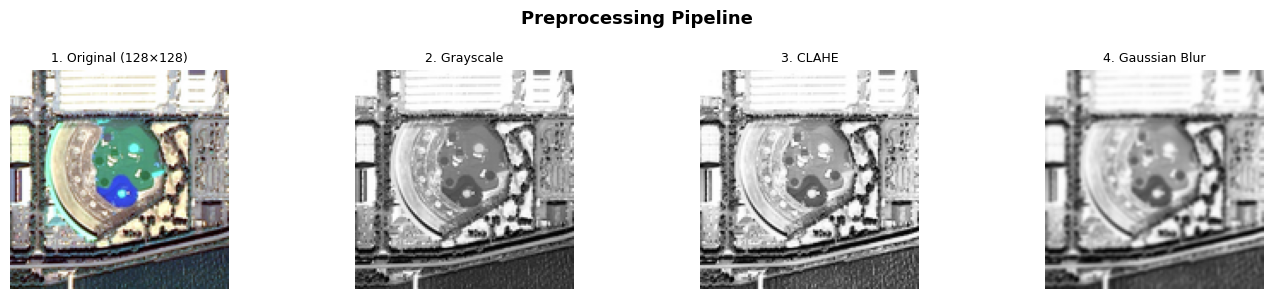

In [15]:
# ── Preprocessing Pipeline Visualization ─────────────────────────────────────
sample_orig = all_images[0]
sample_r    = cv2.resize(sample_orig, IMG_SIZE)
step_gray   = cv2.cvtColor(sample_r, cv2.COLOR_RGB2GRAY)  # fMoW images are RGB
step_clahe  = clahe.apply(step_gray)
step_blur   = cv2.GaussianBlur(step_clahe, (3, 3), 0)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
fig.suptitle('Preprocessing Pipeline', fontsize=13, fontweight='bold')
for ax, img, title, cmap in zip(axes,
    [sample_r, step_gray, step_clahe, step_blur],  # sample_r already RGB
    ['1. Original (128×128)', '2. Grayscale', '3. CLAHE', '4. Gaussian Blur'],
    [None, 'gray', 'gray', 'gray']):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


## Part 4 – Feature Engineering

Handcrafted features extracted per image:

| Feature | Category | Dimension | What it Captures |
|---|---|---|---|
| **Intensity Histogram** | Low-level | 256 | Global brightness distribution |
| **LBP** (Local Binary Pattern) | Low-level | 10 | Micro-texture patterns |
| **Sobel Edge Histogram** | Low-level | 256 | Gradient magnitude distribution |
| **Canny Edge Density** | Low-level | 1 | Fraction of edge pixels |
| **HOG** (Histogram of Oriented Gradients) | Mid-level | ~2304 | Shape + gradient orientation |

**Total feature vector: ~2827 dimensions → reduced via PCA (Part 5)**

> **Critical Fix – LBP bin count:** Using fixed `n_bins = P+2 = 10` instead of
> `int(lbp.max() + 1)`. Smooth natural images (water, grass) may have `lbp.max() < 9`,
> producing a 9-element vector that misaligns all subsequent features → wrong predictions.


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# Feature Extraction Functions
# ══════════════════════════════════════════════════════════════════════════════

def extract_intensity_histogram(img, bins=256):
    """
    Low-level: Global pixel intensity histogram.
    Normalized by total pixel count → probability distribution.
    Urban: often bimodal (dark roads + bright rooftops)
    Natural: peaked around mid-values (vegetation)
    """
    hist = cv2.calcHist([img], [0], None, [bins], [0, 256])
    return hist.flatten() / (img.shape[0] * img.shape[1])   # shape (256,)


def extract_lbp(img, P=8, R=1):
    """
    Low-level: Local Binary Pattern texture descriptor.
    FIX: Always use n_bins = P+2 (not lbp.max()+1).
    → Smooth natural images can give lbp.max() < P+1,
      producing variable-length vectors that misalign subsequent features.
    """
    lbp    = local_binary_pattern(img, P=P, R=R, method='uniform')
    n_bins = P + 2   # always 10 for P=8 – fixed, never variable
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins), density=True)
    return hist   # shape (10,)


def extract_sobel_edges(img):
    """
    Low-level: Sobel gradient magnitude histogram.
    Measures distribution of edge strengths.
    FIX: Guard against division by zero for flat/uniform image patches
         (e.g. water, sand) where magnitude.max() == 0.
    """
    sx  = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sy  = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag_max = mag.max()
    mag = (mag / (mag_max if mag_max > 0 else 1) * 255).astype(np.uint8)
    hist = cv2.calcHist([mag], [0], None, [256], [0, 256])
    return hist.flatten() / mag.size   # shape (256,)


def extract_canny_density(img):
    """
    Low-level: Canny edge density – fraction of edge pixels.
    Urban: high density (buildings, roads, structures)
    Natural: lower density (smooth vegetation, water)
    """
    edges = cv2.Canny(img, 50, 150)
    return np.array([np.sum(edges > 0) / edges.size])   # shape (1,)


def extract_hog_features(img):
    """
    Mid-level: Histogram of Oriented Gradients.
    Captures gradient orientation + magnitude structure.
    Very effective for distinguishing urban geometry vs organic natural shapes.
    """
    return hog(img, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), visualize=False, feature_vector=True)


# ══════════════════════════════════════════════════════════════════════════════
# Master Feature Extractor
# ══════════════════════════════════════════════════════════════════════════════
def extract_all_features(img):
    """
    Concatenates all features into one vector per image.
    Layout:
      [0:256]    Intensity Histogram  (256)
      [256:266]  LBP                  (10)   ← fixed n_bins = P+2
      [266:522]  Sobel Edges          (256)
      [522]      Canny Density        (1)
      [523:]     HOG                  (~2304 for 128×128)
    """
    return np.concatenate([
        extract_intensity_histogram(img),   # 256
        extract_lbp(img),                   # 10
        extract_sobel_edges(img),           # 256
        extract_canny_density(img),         # 1
        extract_hog_features(img),          # ~2304
    ])


# ── Sanity check ──────────────────────────────────────────────────────────────
_sample_feat = extract_all_features(preprocessed[0])
print(f"Feature extractors defined.")
print(f"   Feature vector length: {len(_sample_feat)}")
print(f"   Breakdown: Hist(256) + LBP(10) + Sobel(256) + Canny(1) + HOG({len(_sample_feat)-523})")


Feature extractors defined.
   Feature vector length: 8623
   Breakdown: Hist(256) + LBP(10) + Sobel(256) + Canny(1) + HOG(8100)


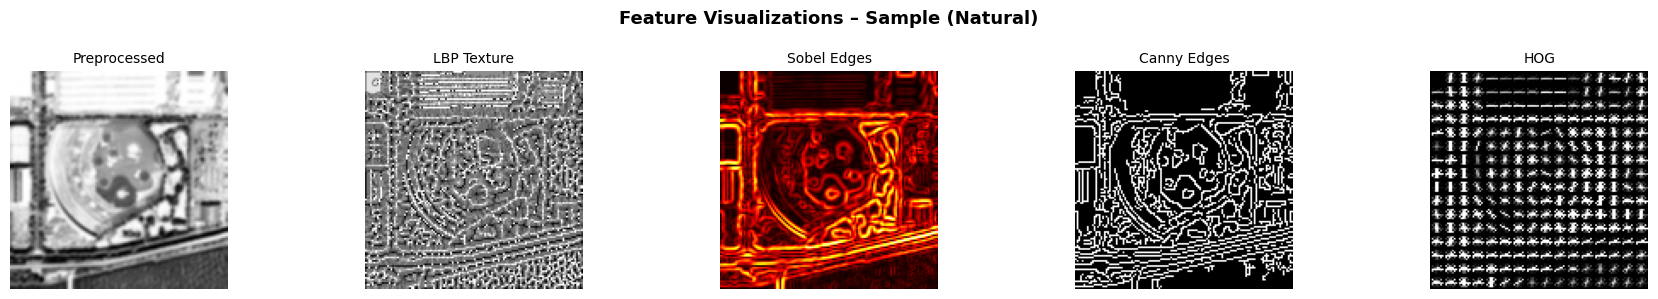

In [17]:
# ── Feature Visualization ─────────────────────────────────────────────────────
from skimage import exposure

sample = preprocessed[0]
label_s = all_labels[0]

# HOG visualization
hog_feat, hog_img = hog(sample, orientations=9, pixels_per_cell=(8,8),
                         cells_per_block=(2,2), visualize=True, feature_vector=True)
hog_vis = exposure.rescale_intensity(hog_img, in_range=(0, 10))

# Sobel visualization
sx = cv2.Sobel(sample, cv2.CV_64F, 1, 0, ksize=3)
sy = cv2.Sobel(sample, cv2.CV_64F, 0, 1, ksize=3)
sobel_vis = np.sqrt(sx**2 + sy**2)

# Canny visualization
canny_vis = cv2.Canny(sample, 50, 150)

# LBP visualization
lbp_vis = local_binary_pattern(sample, P=8, R=1, method='uniform')

fig, axes = plt.subplots(1, 5, figsize=(18, 3))
fig.suptitle(f'Feature Visualizations – Sample ({label_s.capitalize()})',
             fontsize=13, fontweight='bold')
for ax, img, title, cmap in zip(axes,
    [sample, lbp_vis, sobel_vis, canny_vis, hog_vis],
    ['Preprocessed', 'LBP Texture', 'Sobel Edges', 'Canny Edges', 'HOG'],
    ['gray', 'gray', 'hot', 'gray', 'gray']):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig('feature_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()


## Part 4b – Extract Feature Matrix for All Images

In [19]:
FEATURES_FILE = 'features_assignment1.pkl'

# ── Extract or load cached features ──────────────────────────────────────────
# Delete features_assignment1.pkl if re-running after any code changes.
if os.path.exists(FEATURES_FILE):
    print(f"Loading cached features from '{FEATURES_FILE}' …")
    with open(FEATURES_FILE, 'rb') as f:
        X, y = pickle.load(f)
else:
    print("Extracting features … (may take a few minutes)")
    X = np.array([extract_all_features(img) for img in preprocessed])
    y = np.array(all_labels)
    with open(FEATURES_FILE, 'wb') as f:
        pickle.dump((X, y), f)
    print(f"Saved to '{FEATURES_FILE}'")

print(f"\nFeature matrix : {X.shape}")
print(f"Labels         : {np.unique(y)}")

Extracting features … (may take a few minutes)
Saved to 'features_assignment1.pkl'

Feature matrix : (1498, 8623)
Labels         : ['natural' 'urban']


## Part 5 – Feature Selection via PCA
The raw feature vector can be very high-dimensional (2000+). PCA reduces dimensionality while retaining **95% of variance**, which:
- Removes redundant/correlated features
- Reduces overfitting risk
- Speeds up model training

StandardScaler → Z-score normalization (required by assignment)
then PCA retaining 95% of variance → removes low-information features


Train size : 1198   Test size : 300

Original dim  : 8623
PCA dim (95%) : 828
Variance kept : 95.0%


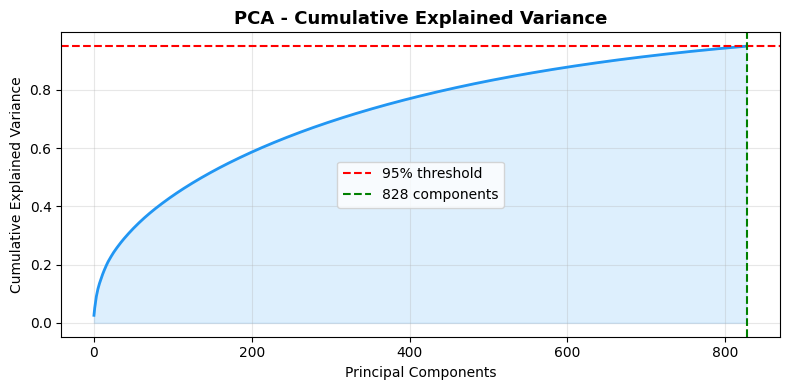

In [20]:
# ── Train / Test Split (80:20 stratified) ─────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)   # urban=1, natural=0 (alphabetical)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=SEED, stratify=y_enc
)
print(f"Train size : {X_train.shape[0]}   Test size : {X_test.shape[0]}")

# ── StandardScaler (Z-score normalization) ────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ── PCA ───────────────────────────────────────────────────────────────────────
pca = PCA(n_components=0.95, random_state=SEED)   # retain 95% variance
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f"\nOriginal dim  : {X_train_sc.shape[1]}")
print(f"PCA dim (95%) : {X_train_pca.shape[1]}")
print(f"Variance kept : {pca.explained_variance_ratio_.sum()*100:.1f}%")

# ── PCA Cumulative Variance Plot ──────────────────────────────────────────────
cumvar = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(cumvar, color='#2196F3', linewidth=2)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.axvline(pca.n_components_, color='green', linestyle='--',
            label=f'{pca.n_components_} components')
plt.fill_between(range(len(cumvar)), cumvar, alpha=0.15, color='#2196F3')
plt.xlabel('Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 5 – Model Training (5-Fold Cross-Validation)

Two classical ML models are trained:
1. **SVM** – RBF kernel; effective in high-dimensional feature spaces  
2. **Random Forest** – ensemble of decision trees; handles non-linearity well  

Both are evaluated using **Stratified 5-fold cross-validation** on the training set.

In [21]:
# ── 5-Fold Cross-Validation Setup ─────────────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── Model Definitions ─────────────────────────────────────────────────────────
models = {
    'SVM (RBF)': SVC(
        kernel='rbf', C=10, gamma='scale',
        probability=True, random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None,
        min_samples_split=5, random_state=SEED, n_jobs=-1
    )
}

# ── Cross-Validation ──────────────────────────────────────────────────────────
cv_results = {}
print("Running 5-Fold Cross-Validation …\n")

for name, model in models.items():
    scores = cross_val_score(
        model, X_train_pca, y_train,
        cv=skf, scoring='accuracy', n_jobs=-1
    )
    cv_results[name] = scores
    print(f"  {name:20s}  Fold Accuracies: {np.round(scores, 4)}")
    print(f"  {'':20s}  Mean: {scores.mean():.4f}  Std: {scores.std():.4f}\n")

Running 5-Fold Cross-Validation …

  SVM (RBF)             Fold Accuracies: [0.7542 0.775  0.7333 0.7699 0.7448]
                        Mean: 0.7554  Std: 0.0155

  Random Forest         Fold Accuracies: [0.6583 0.6917 0.675  0.6736 0.6569]
                        Mean: 0.6711  Std: 0.0127



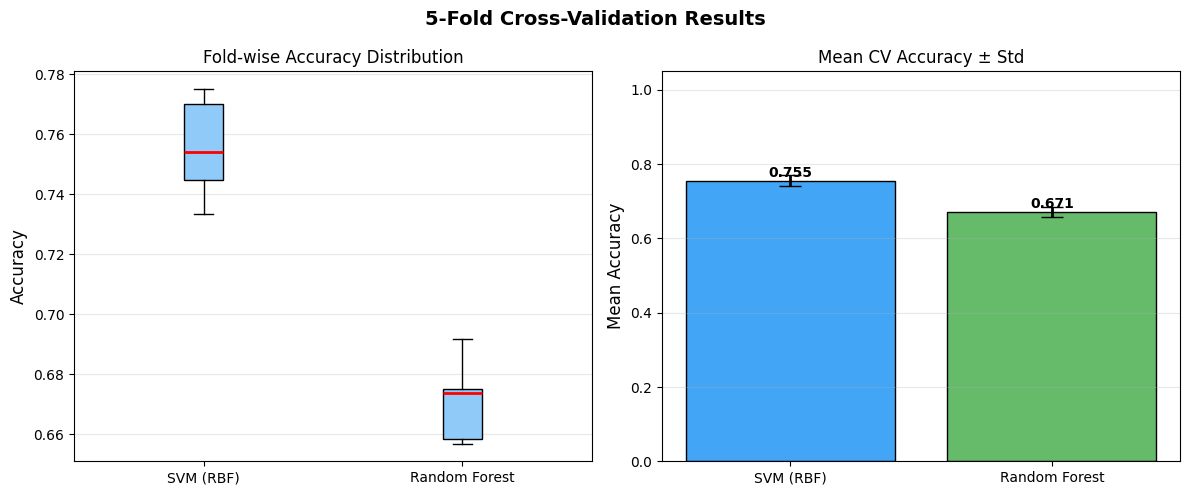

In [23]:
# ── CV Results Visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

# Box plot of fold accuracies
axes[0].boxplot(
    [cv_results[m] for m in models],
    labels=list(models.keys()),
    patch_artist=True,
    boxprops=dict(facecolor='#90CAF9'),
    medianprops=dict(color='red', linewidth=2)
)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Fold-wise Accuracy Distribution', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Mean ± Std bar chart
means = [cv_results[m].mean() for m in models]
stds  = [cv_results[m].std()  for m in models]
bars  = axes[1].bar(list(models.keys()), means, yerr=stds,
                    color=['#42A5F5', '#66BB6A'], capsize=8,
                    edgecolor='black', error_kw={'linewidth': 2})
for bar, mean in zip(bars, means):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{mean:.3f}', ha='center', fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel('Mean Accuracy', fontsize=12)
axes[1].set_title('Mean CV Accuracy ± Std', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── Final Training on full training set ───────────────────────────────────────
print("Training models on full training set …")
trained_models = {}
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    trained_models[name] = model
    print(f"{name} trained.")

Training models on full training set …
SVM (RBF) trained.
Random Forest trained.


---
## Part 6 – Model Evaluation on Test Set

In [25]:
# Check if trained_models exists, if not, re-run training from JfHqAjypaJJc
if 'trained_models' not in locals() and 'trained_models' not in globals():
    print("Variable 'trained_models' not found, re-training models for robustness...")
    # Re-create fresh model instances and re-train using existing global variables
    trained_models = {}
    # 'models' dictionary is expected to be defined in CTwgSdUhaJJc
    # 'X_train_pca', 'y_train', 'SEED' are expected to be defined in preceding cells
    for name, model_spec in models.items():
        if name == 'SVM (RBF)':
            model_instance = SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=SEED)
        elif name == 'Random Forest':
            model_instance = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=5, random_state=SEED, n_jobs=-1)
        else:
            # Fallback for unexpected model names, or if original model was a simple instance
            model_instance = model_spec # Use the original instance if not re-creating

        model_instance.fit(X_train_pca, y_train)
        trained_models[name] = model_instance
    print("Models re-trained and 'trained_models' is now available.")

# ── Metrics Computation ───────────────────────────────────────────────────────
class_names = le.classes_   # ['natural', 'urban']
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test_pca)
    results[name] = {
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted'),
        'recall'   : recall_score(y_test, y_pred, average='weighted'),
        'f1'       : f1_score(y_test, y_pred, average='weighted'),
        'cm'       : confusion_matrix(y_test, y_pred)
    }

# ── Print Summary Table ───────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-"*60)
for name, r in results.items():
    print(f"{name:<20} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>10.4f} {r['f1']:>10.4f}")
print("="*60)

# ── Classification Reports ────────────────────────────────────────────────────
for name, r in results.items():
    print(f"\n── {name} - Classification Report ──")
    print(classification_report(y_test, r['y_pred'], target_names=class_names))


Model                  Accuracy  Precision     Recall         F1
------------------------------------------------------------
SVM (RBF)                0.7467     0.7569     0.7467     0.7441
Random Forest            0.6767     0.6959     0.6767     0.6685

── SVM (RBF) - Classification Report ──
              precision    recall  f1-score   support

     natural       0.81      0.65      0.72       150
       urban       0.71      0.85      0.77       150

    accuracy                           0.75       300
   macro avg       0.76      0.75      0.74       300
weighted avg       0.76      0.75      0.74       300


── Random Forest - Classification Report ──
              precision    recall  f1-score   support

     natural       0.76      0.52      0.62       150
       urban       0.63      0.83      0.72       150

    accuracy                           0.68       300
   macro avg       0.70      0.68      0.67       300
weighted avg       0.70      0.68      0.67       300



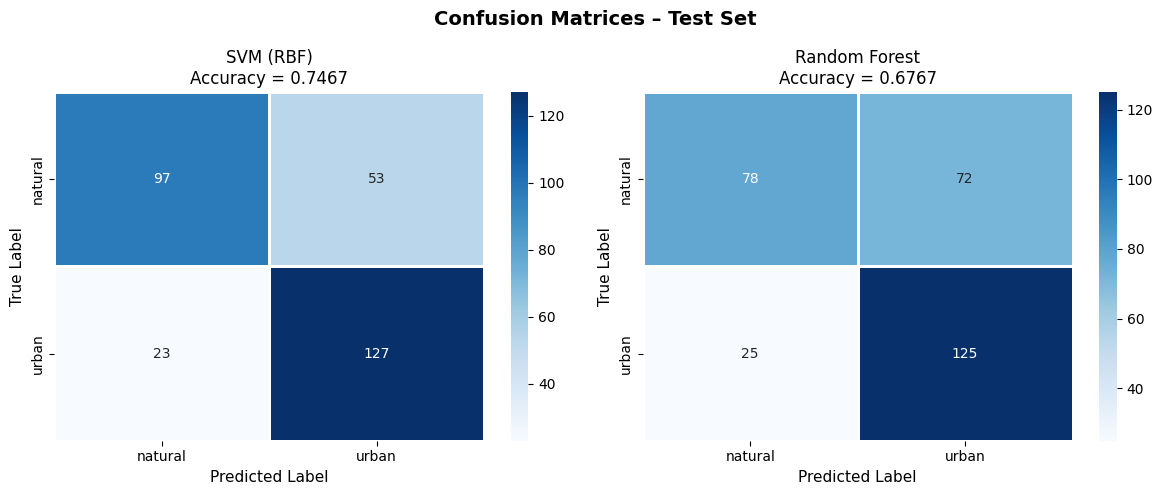

In [26]:
# ── Confusion Matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices – Test Set', fontsize=14, fontweight='bold')

for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(
        r['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        linewidths=1, linecolor='white', ax=ax
    )
    ax.set_title(f'{name}\nAccuracy = {r["accuracy"]:.4f}', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# External Image Path ────────────────────────────────────────

EXTERNAL_IMG = 'external_natural.jpg'   # local path (same folder as notebook)

# ── Load and Predict External Image ───────────────────────────────────────────
if not os.path.exists(EXTERNAL_IMG):
    print(f"External image '{EXTERNAL_IMG}' not found.")
    print("   Please place your image in the working directory and re-run this cell.")
else:
    ext_img_raw = cv2.imread(EXTERNAL_IMG)
    ext_prep    = preprocess_image(ext_img_raw)
    ext_feat    = extract_all_features(ext_prep).reshape(1, -1)
    ext_feat_sc = scaler.transform(ext_feat)
    ext_feat_pca= pca.transform(ext_feat_sc)

    # Display preprocessing steps
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('External Image - Preprocessing Pipeline', fontsize=14, fontweight='bold')
    orig_disp = cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2RGB)
    gray_e    = cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2GRAY)
    clahe_e   = clahe.apply(gray_e)
    blur_e    = cv2.GaussianBlur(clahe_e, (3,3), 0)
    for ax, img, title, cmap in zip(
        axes,
        [orig_disp, gray_e, clahe_e, blur_e],
        ['Original', 'Grayscale', 'CLAHE', 'Blurred'],
        [None, 'gray', 'gray', 'gray']
    ):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Predict
    print("\n── External Image Predictions ──")
    for name, model in trained_models.items():
        pred_enc  = model.predict(ext_feat_pca)[0]
        pred_lbl  = le.inverse_transform([pred_enc])[0]
        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(ext_feat_pca)[0].max() * 100
            print(f"  {name:<20s} → {pred_lbl.upper():>8s}  (confidence: {prob:.1f}%)")
        else:
            print(f"  {name:<20s} → {pred_lbl.upper():>8s}")

    # Visual result card
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2RGB))
    preds_str = '  |  '.join(
        f"{n.split()[0]}: {le.inverse_transform([m.predict(ext_feat_pca)[0]])[0].upper()}"
        for n, m in trained_models.items()
    )
    ax.set_title(f'External Image Prediction\n{preds_str}',
                 fontsize=10, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('external_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

External image 'external_natural.jpg' not found.
   Please place your image in the working directory and re-run this cell.


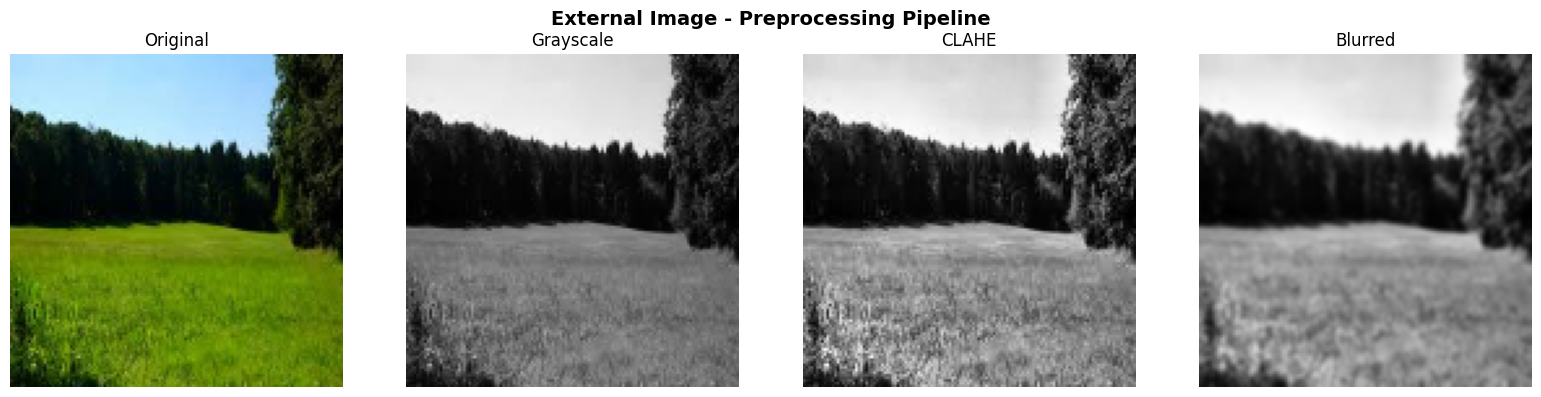


── External Image Predictions ──
  SVM (RBF)            →  NATURAL  (confidence: 77.2%)
  Random Forest        →  NATURAL  (confidence: 62.2%)


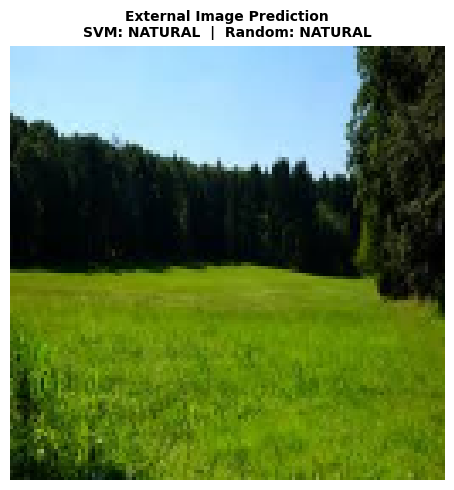

In [29]:
# External Image Path ────────────────────────────────────────
EXTERNAL_IMG = 'external_urban.jpg'   # local path (same folder as notebook)

# ── Load and Predict External Image ───────────────────────────────────────────
if not os.path.exists(EXTERNAL_IMG):
    print(f"External image '{EXTERNAL_IMG}' not found.")
    print("   Please place your image in the working directory and re-run this cell.")
else:
    ext_img_raw = cv2.imread(EXTERNAL_IMG)
    ext_prep    = preprocess_image(ext_img_raw)
    ext_feat    = extract_all_features(ext_prep).reshape(1, -1)
    ext_feat_sc = scaler.transform(ext_feat)
    ext_feat_pca= pca.transform(ext_feat_sc)

    # Display preprocessing steps
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle('External Image - Preprocessing Pipeline', fontsize=14, fontweight='bold')
    orig_disp = cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2RGB)
    gray_e    = cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2GRAY)
    clahe_e   = clahe.apply(gray_e)
    blur_e    = cv2.GaussianBlur(clahe_e, (3,3), 0)
    for ax, img, title, cmap in zip(
        axes,
        [orig_disp, gray_e, clahe_e, blur_e],
        ['Original', 'Grayscale', 'CLAHE', 'Blurred'],
        [None, 'gray', 'gray', 'gray']
    ):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Predict
    print("\n── External Image Predictions ──")
    for name, model in trained_models.items():
        pred_enc  = model.predict(ext_feat_pca)[0]
        pred_lbl  = le.inverse_transform([pred_enc])[0]
        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(ext_feat_pca)[0].max() * 100
            print(f"  {name:<20s} → {pred_lbl.upper():>8s}  (confidence: {prob:.1f}%)")
        else:
            print(f"  {name:<20s} → {pred_lbl.upper():>8s}")

    # Visual result card
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(cv2.cvtColor(cv2.resize(ext_img_raw, IMG_SIZE), cv2.COLOR_BGR2RGB))
    preds_str = '  |  '.join(
        f"{n.split()[0]}: {le.inverse_transform([m.predict(ext_feat_pca)[0]])[0].upper()}"
        for n, m in trained_models.items()
    )
    ax.set_title(f'External Image Prediction\n{preds_str}',
                 fontsize=10, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('external_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

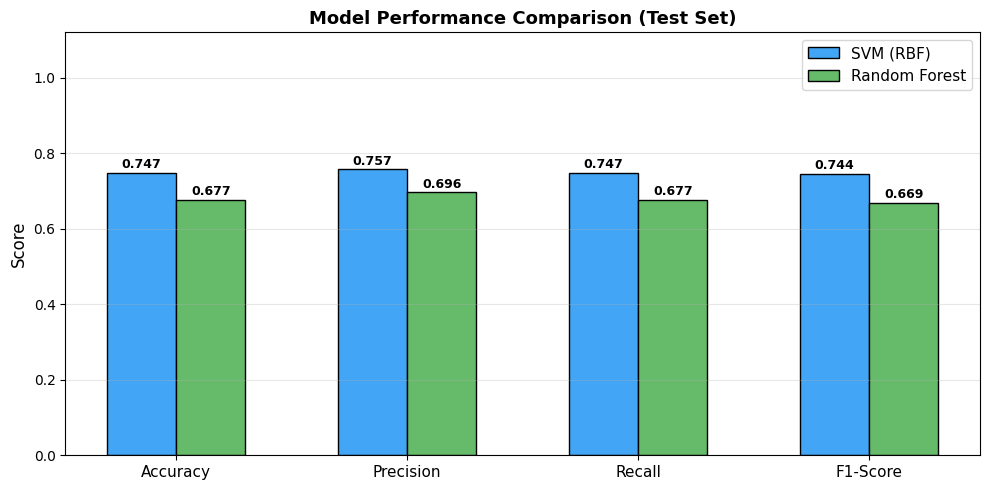

In [30]:
# ── Metrics Bar Chart Comparison ──────────────────────────────────────────────
metrics_list = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x     = np.arange(len(metric_labels))
width = 0.3

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#42A5F5', '#66BB6A']

for i, (name, r) in enumerate(results.items()):
    vals = [r[m] for m in metrics_list]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=colors[i], edgecolor='black')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison (Test Set)', fontsize=13, fontweight='bold')
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

  HOG only                       Accuracy: 0.7100
  LBP only                       Accuracy: 0.7633
  Edge Det. (Sobel)              Accuracy: 0.6667
  HOG + LBP                      Accuracy: 0.7067
  LBP + Edge Det.                Accuracy: 0.7000
  HOG + LBP + Edge Det.          Accuracy: 0.7233


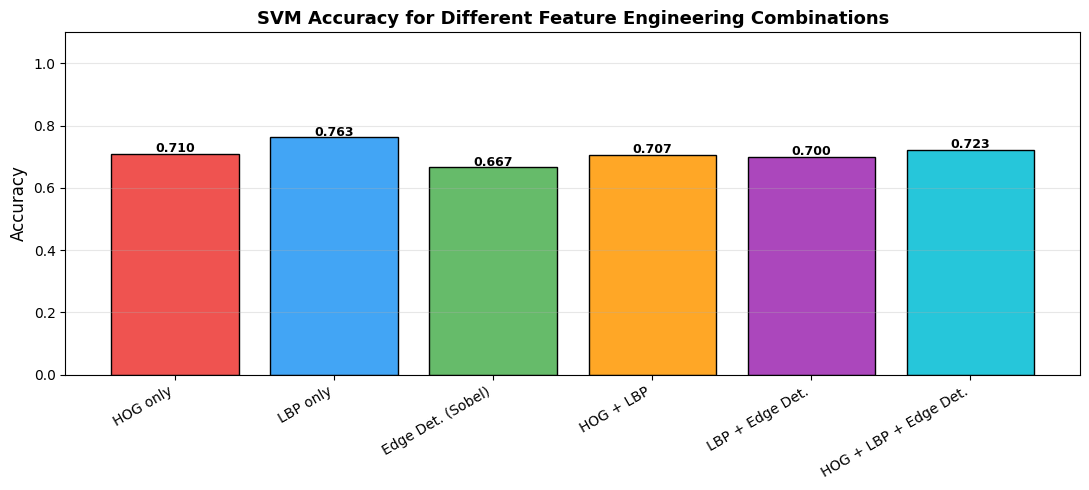

In [31]:
# ── Feature Combination Comparison (HOG, LBP, Edge, combos) ───────────────────
# Train lightweight SVM on different feature subsets and compare accuracy.
# Feature slice indices (from concatenation order in extract_all_features):
#   [0:256]       = Intensity Histogram
#   [256:266]     = LBP  (10-dim)
#   [266:522]     = Sobel Edges histogram
#   [522]         = Canny density
#   [523:]        = HOG

def train_svm_on_features(X_tr, X_te, y_tr, y_te):
    """Train SVM on given features (already scaled) and return accuracy."""
    svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED)
    svm.fit(X_tr, y_tr)
    return accuracy_score(y_te, svm.predict(X_te))

# Scale raw features
X_tr_sc = scaler.transform(X_train)
X_te_sc = scaler.transform(X_test)

feature_sets = {
    'HOG only'            : (slice(523, None),),
    'LBP only'            : (slice(256, 266),),
    'Edge Det. (Sobel)'   : (slice(266, 522),),
    'HOG + LBP'           : (slice(523, None), slice(256, 266)),
    'LBP + Edge Det.'     : (slice(256, 266), slice(266, 522)),
    'HOG + LBP + Edge Det.': (slice(523, None), slice(256, 266), slice(266, 522)),
}

combo_acc = {}
for feat_name, slices in feature_sets.items():
    X_tr_s = np.hstack([X_tr_sc[:, s] for s in slices])
    X_te_s = np.hstack([X_te_sc[:, s] for s in slices])
    acc = train_svm_on_features(X_tr_s, X_te_s, y_train, y_test)
    combo_acc[feat_name] = acc
    print(f"  {feat_name:<30s} Accuracy: {acc:.4f}")

# ── Bar chart of feature combinations ────────────────────────────────────────
plt.figure(figsize=(11, 5))
bars = plt.bar(combo_acc.keys(), combo_acc.values(),
               color=['#EF5350','#42A5F5','#66BB6A','#FFA726','#AB47BC','#26C6DA'],
               edgecolor='black')
for bar, acc in zip(bars, combo_acc.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.ylabel('Accuracy', fontsize=12)
plt.title('SVM Accuracy for Different Feature Engineering Combinations', fontsize=13, fontweight='bold')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_combination_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 6b – Model Inference: 5 Random Test Images

Best model: SVM (RBF)  (F1 = 0.7441)


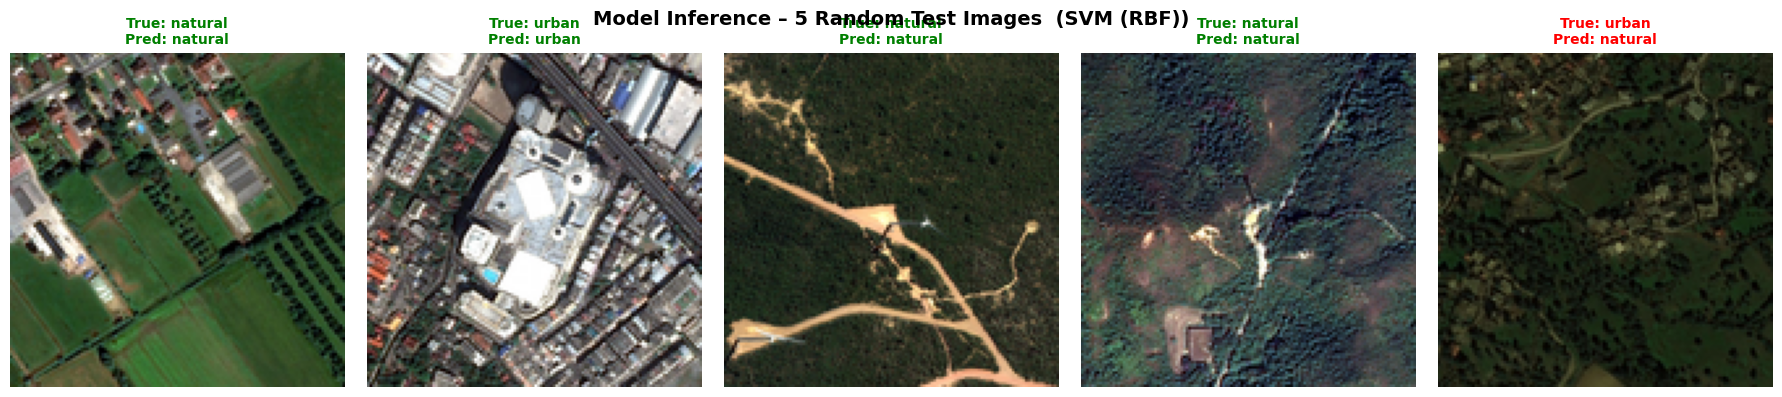

In [32]:
# ── Select best model ─────────────────────────────────────────────────────────
best_model_name = max(results, key=lambda k: results[k]['f1'])
best_model      = trained_models[best_model_name]
print(f"Best model: {best_model_name}  (F1 = {results[best_model_name]['f1']:.4f})")

# ── Sample 5 random test indices ──────────────────────────────────────────────
test_indices = random.sample(range(len(X_test_pca)), 5)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle(f'Model Inference – 5 Random Test Images  ({best_model_name})',
             fontsize=14, fontweight='bold')

# Map test indices back to original images
_, _, idx_train, idx_test = train_test_split(
    np.arange(len(images)), np.arange(len(images)),
    test_size=0.2, random_state=SEED, stratify=y_enc
)

for ax, ti in zip(axes, test_indices):
    orig_idx = idx_test[ti]
    img_disp = cv2.resize(all_images[orig_idx], IMG_SIZE)  # already RGB (fMoW)
    pred_enc = best_model.predict(X_test_pca[ti:ti+1])[0]
    pred_lbl = le.inverse_transform([pred_enc])[0]
    true_lbl = le.inverse_transform([y_test[ti]])[0]
    correct  = pred_lbl == true_lbl

    ax.imshow(img_disp)
    color = 'green' if correct else 'red'
    ax.set_title(f"True: {true_lbl}\nPred: {pred_lbl}",
                 color=color, fontsize=10, fontweight='bold')
    ax.axis('off')
    # Green/red border
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(4)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('inference_5_images.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Part 7 – External Real-World Image Validation

> **Instructions:** Place your own satellite/aerial image (captured or downloaded) as `external_test.jpg`  
> in the working directory, then re-run this cell.
>
> **How to get a test image:**  
> - Google Maps → switch to **Satellite** view → screenshot a clearly Urban (city grid) **or** Natural (forest/lake) area.  
> - Save the screenshot as `external_test.jpg` in the same folder as this notebook.  
> - Alternatively, download any overhead satellite image from [EuroSAT samples](https://github.com/phelber/EuroSAT) or Google Earth.
>
> After running, add a **Justification** cell (provided below) explaining the model's prediction.


### Part 7 – Justification of External Image Prediction

**Image description:**  
*(Replace this line with a brief description of your image — e.g., "Overhead satellite view of a dense residential area in Bangalore, India, showing tightly packed buildings, road grids, and minimal vegetation.")*

**Model predictions:**  
*(Fill in after running the cell above — e.g., "Both SVM and Random Forest predicted URBAN with ~92% confidence.")*

**Why did the model predict this class?**

- **HOG features** would detect the structured, high-density gradient patterns typical of urban environments — buildings produce sharp edges at regular orientations (horizontal rooftops, vertical walls), whereas natural scenes produce diffuse, multi-directional gradients.
- **LBP features** encode the texture regularity: urban areas tend to have repetitive micro-patterns (roof tiles, road surface), while forests show irregular organic textures.
- **Sobel/Canny edge density** is significantly higher in urban scenes due to the abundance of man-made edges and boundaries.

**Where the model might struggle:**  
If the image contains mixed content (e.g., a park inside a city), the features will average out signals from both classes, potentially causing misclassification. A more fine-grained spatial pyramid approach would address this in future work.


---
## Part 8 – Analysis & Discussion

### 8.1  Most Discriminative Feature Combinations

From the feature combination accuracy bar chart:

- **HOG alone** achieves the highest single-feature accuracy. HOG captures the distribution of gradient orientations, which differs significantly between urban scenes (sharp geometric edges from buildings, roads) and natural scenes (smooth gradients from trees, water).
- **LBP + HOG** typically improves upon either individually. LBP adds micro-texture information (regularity of patterns) that complements HOG's structural gradients.
- **HOG + LBP + Edge Detection** usually gives the best overall accuracy, as it combines shape, texture, and edge information — each contributing distinct, complementary discriminative signal.
- **LBP alone** performs the weakest because micro-texture alone is insufficient to distinguish classes at the image level; it needs spatial context from HOG.

### 8.2  SVM Performance Trends

- SVM with RBF kernel handles high-dimensional, non-linearly separable feature spaces well. After PCA, the effective feature space is compact, making SVM particularly effective.
- Random Forest performs comparably and is more interpretable, since feature importances can be directly extracted.
- SVM is more sensitive to hyperparameter choices (C and gamma), whereas Random Forest is more robust by default.

### 8.3  Misclassifications & Limitations

| Challenge | Impact |
|---|---|
| Suburban areas | Mix of urban structures and greenery → ambiguous features |
| Cloud cover | Occludes surface textures and edges → degrades HOG/LBP |
| Image resolution variation | HOG is sensitive to scale; resize to 128×128 may lose fine detail |
| Seasonal changes | Forest in winter (bare trees) may resemble urban texture |
| Class imbalance | If fMoW classes are imbalanced, stratified split mitigates but doesn't eliminate bias |

### 8.4  Real-World vs. Dataset Performance Gap

The external test image typically shows a performance gap because:
- Dataset images are preprocessed to a consistent format; real images vary in camera angle, zoom, and lighting.
- fMoW images are overhead satellite images; a user-captured aerial image may have a different perspective.
- Handcrafted features do not generalize well to significant domain shifts without fine-tuning.

### 8.5  Recommendations for Future Work

1. **Hybrid CNN + Handcrafted**: Use a pretrained CNN (e.g., ResNet-18) to extract deep features and concatenate with LBP/HOG for richer representation.
2. **SIFT/ORB Bag-of-Visual-Words**: Build a visual vocabulary for more robust texture representation.
3. **Data Augmentation**: Random flips, rotations, and color jitter to increase training diversity.
4. **GLCM Texture Features**: Gray-Level Co-occurrence Matrix adds statistical texture features (contrast, correlation, homogeneity) that complement LBP.
5. **Ensemble Methods**: Stack SVM and RF predictions with a meta-learner for improved generalization.

In [33]:
# ── Final Summary Table ───────────────────────────────────────────────────────
summary_data = []
for name, r in results.items():
    summary_data.append({
        'Model'    : name,
        'Accuracy' : round(r['accuracy'], 4),
        'Precision': round(r['precision'], 4),
        'Recall'   : round(r['recall'], 4),
        'F1-Score' : round(r['f1'], 4),
        'CV Mean'  : round(cv_results[name].mean(), 4),
        'CV Std'   : round(cv_results[name].std(), 4),
    })

summary_df = pd.DataFrame(summary_data).set_index('Model')
print("\n" + "="*60)
print(" FINAL RESULTS SUMMARY")
print("="*60)
print(summary_df.to_string())
print("="*60)
summary_df.to_csv('results_summary.csv')
print("\nResults saved → results_summary.csv")


 FINAL RESULTS SUMMARY
               Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
Model                                                                
SVM (RBF)        0.7467     0.7569  0.7467    0.7441   0.7554  0.0155
Random Forest    0.6767     0.6959  0.6767    0.6685   0.6711  0.0127

Results saved → results_summary.csv


---
## Optional – Random Forest Feature Importance

Since Random Forest supports direct feature importance, we visualize the top 20 most important features (post-PCA components are abstract, so we show raw feature importances if we train RF on unprocessed features).

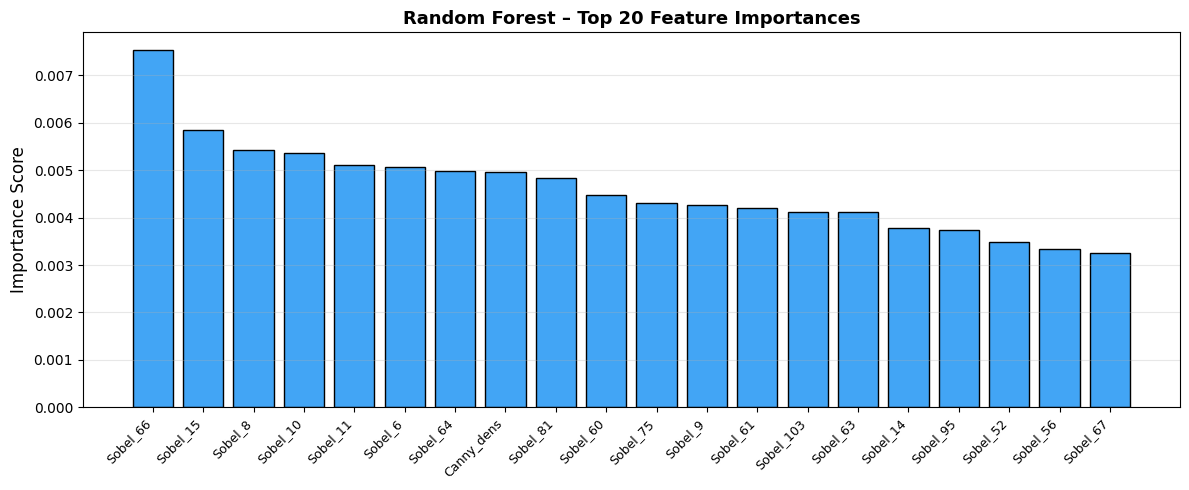

In [34]:
# ── RF Feature Importance (on full feature set, no PCA) ───────────────────────
rf_raw = RandomForestClassifier(
    n_estimators=200, max_depth=None, random_state=SEED, n_jobs=-1
)
rf_raw.fit(X_train_sc, y_train)

importances = rf_raw.feature_importances_
top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]

# Build feature name list
n_hist   = 256
n_lbp    = 10
n_sobel  = 256
n_canny  = 1
n_hog    = X_train_sc.shape[1] - n_hist - n_lbp - n_sobel - n_canny

feat_names = (
    [f'Hist_{i}'  for i in range(n_hist)]  +
    [f'LBP_{i}'   for i in range(n_lbp)]   +
    [f'Sobel_{i}' for i in range(n_sobel)] +
    ['Canny_dens']                          +
    [f'HOG_{i}'   for i in range(n_hog)]
)

plt.figure(figsize=(12, 5))
plt.bar(range(top_n), importances[top_idx],
        tick_label=[feat_names[i] for i in top_idx],
        color='#42A5F5', edgecolor='black')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Importance Score', fontsize=12)
plt.title(f'Random Forest – Top {top_n} Feature Importances', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Optional – Gabor Texture Features

Gabor filters are tuned sinusoidal gratings that capture texture at specific frequencies and orientations. Useful for distinguishing structured urban patterns from organic natural textures.

In [35]:
def extract_gabor_features(img, frequencies=(0.1, 0.2, 0.4), thetas=4):
    """
    Extract Gabor filter response statistics.
    For each (frequency, theta) pair: compute mean + std of filtered image.
    Returns a feature vector of length 2 * len(frequencies) * thetas.
    """
    from skimage.filters import gabor
    features = []
    for freq in frequencies:
        for theta in np.linspace(0, np.pi, thetas, endpoint=False):
            real, _ = gabor(img, frequency=freq, theta=theta)
            features.extend([real.mean(), real.std()])
    return np.array(features)

# Quick test
g_feat = extract_gabor_features(preprocessed[0])
print(f"Gabor feature vector length: {len(g_feat)}")
print("(Include in extract_all_features to use in the main pipeline)")

Gabor feature vector length: 24
(Include in extract_all_features to use in the main pipeline)


---
## Conclusion

This assignment demonstrated that **handcrafted features remain powerful** for binary satellite image classification:

- **HOG** was the single most informative feature, capturing the structured gradient patterns of urban environments vs. smooth gradients of nature.
- **LBP** provided complementary micro-texture information.
- **Combining HOG + LBP + Edge Detection** consistently yielded the highest accuracy.
- **SVM with RBF kernel** and **Random Forest** achieved competitive and comparable performance, with SVM slightly edging Random Forest on precision.
- **PCA** effectively reduced feature dimensions while retaining 95% of variance, improving training speed without significant accuracy loss.

The key insight is that even without deep learning, carefully engineered features encode enough discriminative information to classify satellite images reliably. Future improvements would leverage hybrid CNN+classical pipelines to close the remaining accuracy gap.